# PWAVE-L

P-WAVE Velocity

In [1]:
# force Jupyter to autoreload modules when they have been edited
# this helps keep the iodp module current as it is actively developed.
%load_ext autoreload
%autoreload 2

In [69]:
import sys
import os
from importlib import reload

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from iodp import utils, pwavel



In [3]:
# Ensure we are in the PhysicalProperties root folder
if not os.getcwd().endswith("PhysicalProperties"):
    print("Current working directory:", os.getcwd())
    os.chdir("../")
    
print("New current working directory:", os.getcwd())

Current working directory: d:\archive\hd_files\data_analysis\50_laboratory_notebooks\SOD-Laboratory\PhysicalProperties\notebooks
New current working directory: d:\archive\hd_files\data_analysis\50_laboratory_notebooks\SOD-Laboratory\PhysicalProperties


## Read PWAVE-L .PWAVE_L files

In [85]:
file = './data/input/PWAVE-L/400-U1604A-2H-7_20230903203248.PWAVE_L'
df = utils.read_instrument_file(file,as_dataframe=True)
df

,datetime,labelid,user,text_id,instrument,instrument_group,observed_length,comment,system_delay,laser_distance_corr,...,threshold,stack,velocity_wfm,config,positions_excluded,offset,distance_in_caliper,travel_time,velocity_xy,timestamp
0,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,4.90,62.857,40.247,1561.77,2023-09-03 20:31:13
1,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,6.90,62.588,39.467,1585.83,2023-09-03 20:31:18
2,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,8.90,62.425,51.308,1216.66,2023-09-03 20:31:23
3,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,12.90,62.296,60.587,1028.20,2023-09-03 20:31:32
4,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,14.90,62.301,41.211,1511.75,2023-09-03 20:31:36
5,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,16.90,62.327,41.455,1503.48,2023-09-03 20:31:45
6,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,18.90,62.327,41.714,1494.15,2023-09-03 20:31:51
7,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,20.90,62.325,41.812,1490.61,2023-09-03 20:31:54
8,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,22.90,62.320,41.645,1496.46,2023-09-03 20:31:57
9,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,24.90,62.317,41.661,1495.81,2023-09-03 20:32:01


## Read PWAVE-L .ini files

In [86]:
file = './data/input/PWAVE-L/i_pi_pwave.ini'
df = utils.read_instrument_ini(file,as_dataframe=True)
df

,value
key,
mgi rwa section options,2.0.1 %04Y%02m%02d %02H%02M%S%25u*~|.%d*~|....
ims framework-major,14
ims framework-minor,0
plugin-major,0
plugin-minor,0
...,...
track type?,WRMSL
aluminum standards.thickness,76.25
aluminum standards.velocity,6295


## Read PWAVE-L .csv files

In [87]:
file = "./data/input/PWAVE-L/raw_400-u1604a-2h-7_2309032032483_pwave-l.csv"
df = pwavel.read_pwavel_csv(file)
df

,offset(cm),velocity_xy(m/s),travel_time(s),distance_in_caliper(mm),liner_thickness(mm),liner_delay(s),laser_distance(mm),Temperature C,t0(s),dt(s),...,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
0,4.9,1561.77,0.000040,62.857,2.58,0.000002,68.02,0.0,0.0,1.000000e-08,...,0.0012,0.0012,-0.0156,-0.0493,-0.0661,-0.0661,-0.0493,-0.0325,-0.0156,-0.0325
1,6.9,1585.83,0.000039,62.588,2.58,0.000002,67.75,0.0,0.0,1.000000e-08,...,-0.0829,0.0012,0.0854,0.1190,0.0854,0.0180,0.0012,-0.0156,-0.0156,0.0012
2,8.9,1216.66,0.000051,62.425,2.58,0.000002,67.58,0.0,0.0,1.000000e-08,...,0.0180,0.0180,0.0180,0.0349,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180
3,12.9,1028.20,0.000061,62.296,2.58,0.000002,67.46,0.0,0.0,1.000000e-08,...,0.0012,0.0012,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180
4,14.9,1511.75,0.000041,62.301,2.58,0.000002,67.46,0.0,0.0,1.000000e-08,...,0.0012,0.0012,0.0012,0.0012,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180
5,16.9,1503.48,0.000041,62.327,2.58,0.000002,67.49,0.0,0.0,1.000000e-08,...,-0.0325,-0.0493,-0.0325,-0.0156,-0.0156,0.0012,0.0180,0.0180,0.0012,0.0012
6,18.9,1494.15,0.000042,62.327,2.58,0.000002,67.49,0.0,0.0,1.000000e-08,...,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,0.0012
7,20.9,1490.61,0.000042,62.325,2.58,0.000002,67.48,0.0,0.0,1.000000e-08,...,-0.0493,-0.0493,-0.0493,-0.0493,-0.0493,-0.0493,-0.0493,-0.0661,-0.0493,-0.0493
8,22.9,1496.46,0.000042,62.320,2.58,0.000002,67.48,0.0,0.0,1.000000e-08,...,-0.0325,-0.0325,-0.0493,-0.0493,-0.0325,-0.0325,-0.0493,-0.0493,-0.0493,-0.0493
9,24.9,1495.81,0.000042,62.317,2.58,0.000002,67.48,0.0,0.0,1.000000e-08,...,-0.0325,-0.0156,-0.0156,-0.0325,-0.0493,-0.0661,-0.0661,-0.0493,-0.0493,-0.0325


# Exploring PWAVE-L

In [88]:
file = "./data/input/PWAVE-L/raw_400-u1604a-2h-7_2309032032483_pwave-l.csv"
df = pwavel.read_pwavel_csv(file)
df

,offset(cm),velocity_xy(m/s),travel_time(s),distance_in_caliper(mm),liner_thickness(mm),liner_delay(s),laser_distance(mm),Temperature C,t0(s),dt(s),...,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
0,4.9,1561.77,0.000040,62.857,2.58,0.000002,68.02,0.0,0.0,1.000000e-08,...,0.0012,0.0012,-0.0156,-0.0493,-0.0661,-0.0661,-0.0493,-0.0325,-0.0156,-0.0325
1,6.9,1585.83,0.000039,62.588,2.58,0.000002,67.75,0.0,0.0,1.000000e-08,...,-0.0829,0.0012,0.0854,0.1190,0.0854,0.0180,0.0012,-0.0156,-0.0156,0.0012
2,8.9,1216.66,0.000051,62.425,2.58,0.000002,67.58,0.0,0.0,1.000000e-08,...,0.0180,0.0180,0.0180,0.0349,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180
3,12.9,1028.20,0.000061,62.296,2.58,0.000002,67.46,0.0,0.0,1.000000e-08,...,0.0012,0.0012,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180
4,14.9,1511.75,0.000041,62.301,2.58,0.000002,67.46,0.0,0.0,1.000000e-08,...,0.0012,0.0012,0.0012,0.0012,0.0180,0.0180,0.0180,0.0180,0.0180,0.0180
5,16.9,1503.48,0.000041,62.327,2.58,0.000002,67.49,0.0,0.0,1.000000e-08,...,-0.0325,-0.0493,-0.0325,-0.0156,-0.0156,0.0012,0.0180,0.0180,0.0012,0.0012
6,18.9,1494.15,0.000042,62.327,2.58,0.000002,67.49,0.0,0.0,1.000000e-08,...,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,-0.0156,0.0012
7,20.9,1490.61,0.000042,62.325,2.58,0.000002,67.48,0.0,0.0,1.000000e-08,...,-0.0493,-0.0493,-0.0493,-0.0493,-0.0493,-0.0493,-0.0493,-0.0661,-0.0493,-0.0493
8,22.9,1496.46,0.000042,62.320,2.58,0.000002,67.48,0.0,0.0,1.000000e-08,...,-0.0325,-0.0325,-0.0493,-0.0493,-0.0325,-0.0325,-0.0493,-0.0493,-0.0493,-0.0493
9,24.9,1495.81,0.000042,62.317,2.58,0.000002,67.48,0.0,0.0,1.000000e-08,...,-0.0325,-0.0156,-0.0156,-0.0325,-0.0493,-0.0661,-0.0661,-0.0493,-0.0493,-0.0325


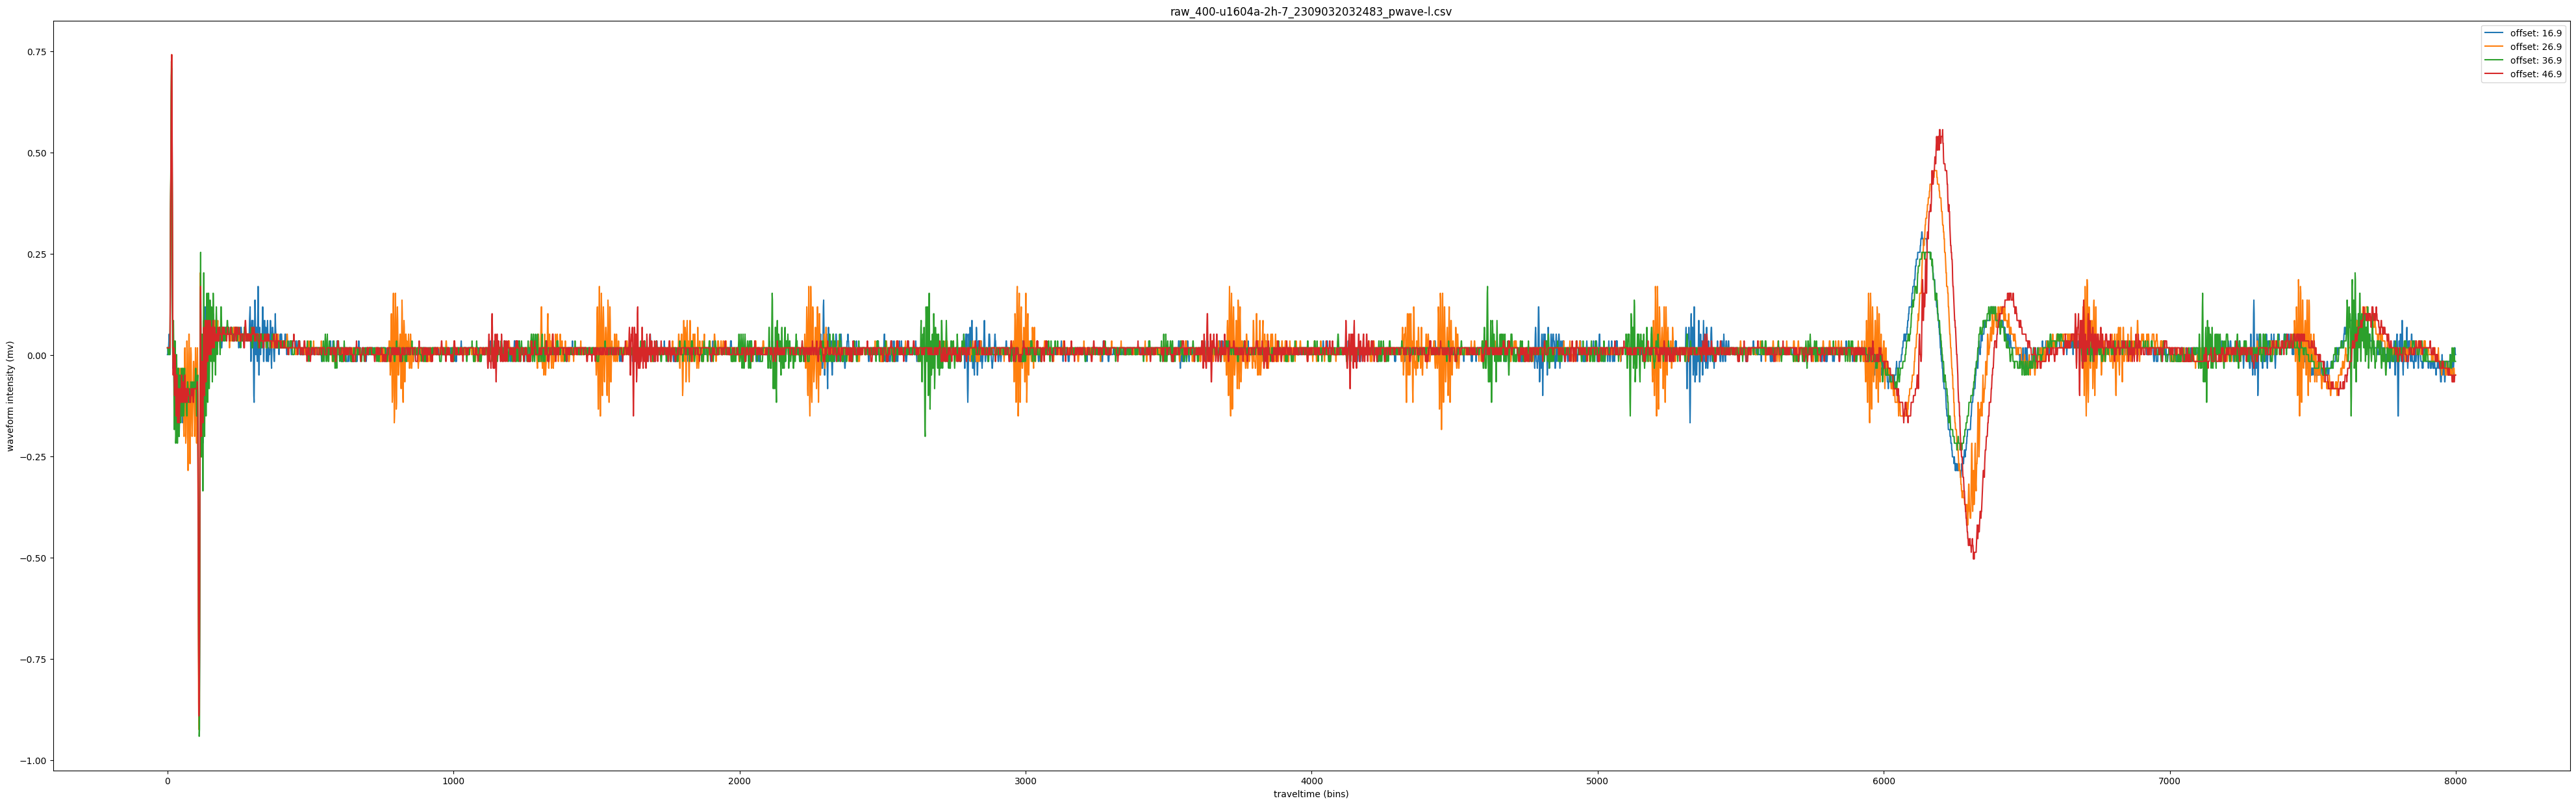

In [89]:
fig, ax = plt.subplots(1,1,figsize=(50,15))

rows = [5,10,15,20]

for row in rows:
        ax.plot(df.columns[10:],
                df.iloc[row, 10:],
                label=f"offset: {df.loc[row,'offset(cm)']}"
                )
ax.set_xlabel("traveltime (bins)")
ax.set_ylabel('waveform intensity (mv)')
ax.set_title(f"{os.path.split(file)[-1]}")
ax.legend()
plt.show()

In [94]:
file = './data/input/PWAVE-L/400-U1604A-2H-7_20230903203248.PWAVE_L'
df = utils.read_instrument_file(file,as_dataframe=True)
df.head()

,datetime,labelid,user,text_id,instrument,instrument_group,observed_length,comment,system_delay,laser_distance_corr,...,threshold,stack,velocity_wfm,config,positions_excluded,offset,distance_in_caliper,travel_time,velocity_xy,timestamp
0,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,4.90,62.857,40.247,1561.77,2023-09-03 20:31:13
1,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,6.90,62.588,39.467,1585.83,2023-09-03 20:31:18
2,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,8.90,62.425,51.308,1216.66,2023-09-03 20:31:23
3,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,12.90,62.296,60.587,1028.20,2023-09-03 20:31:32
4,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,14.90,62.301,41.211,1511.75,2023-09-03 20:31:36


[]

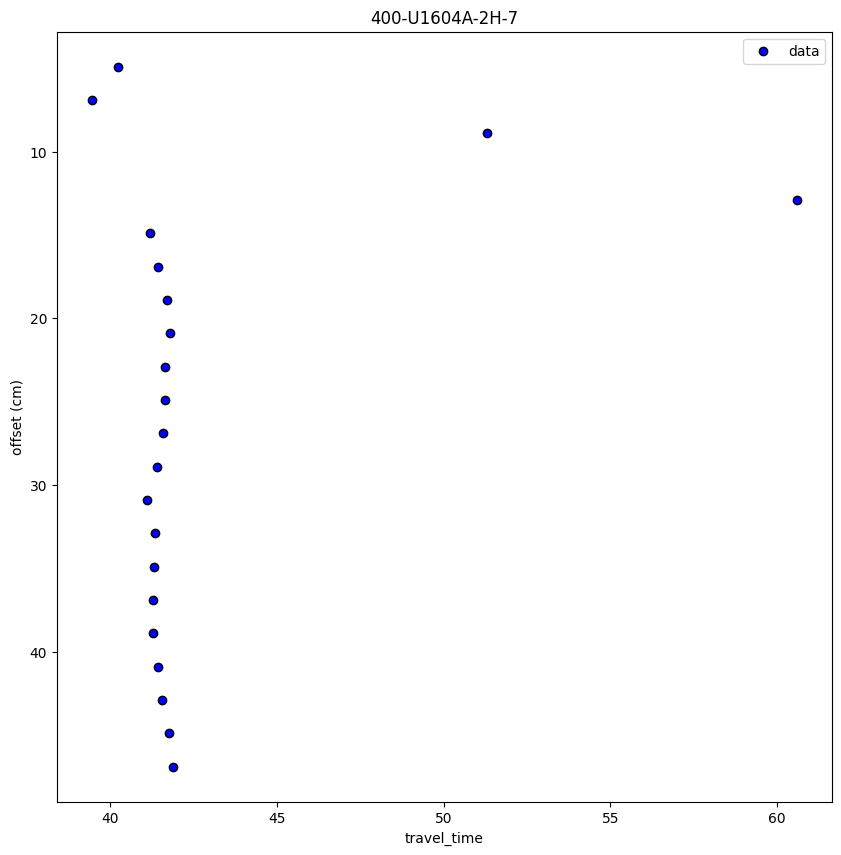

In [96]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

x = df["travel_time"].astype(float)
y = df['offset'].astype(float)

ax.scatter(
    x=x,
    y=y,
    label='data',
    color='blue',
    edgecolor='black'
)

# windowsize = 5
# ax.plot(
#     utils.convolve(x,windowsize),
#     y,
#     label=f'avg {windowsize} pts'
# )


ax.invert_yaxis()
ax.set_ylabel("offset (cm)")
ax.set_xlabel("travel_time")
ax.set_title(f"{df['labelid'][0]}")
ax.legend()
plt.plot()

In [98]:
df

,datetime,labelid,user,text_id,instrument,instrument_group,observed_length,comment,system_delay,laser_distance_corr,...,threshold,stack,velocity_wfm,config,positions_excluded,offset,distance_in_caliper,travel_time,velocity_xy,timestamp
0,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,4.90,62.857,40.247,1561.77,2023-09-03 20:31:13
1,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,6.90,62.588,39.467,1585.83,2023-09-03 20:31:18
2,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,8.90,62.425,51.308,1216.66,2023-09-03 20:31:23
3,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,12.90,62.296,60.587,1028.20,2023-09-03 20:31:32
4,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,14.90,62.301,41.211,1511.75,2023-09-03 20:31:36
5,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,16.90,62.327,41.455,1503.48,2023-09-03 20:31:45
6,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,18.90,62.327,41.714,1494.15,2023-09-03 20:31:51
7,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,20.90,62.325,41.812,1490.61,2023-09-03 20:31:54
8,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,22.90,62.320,41.645,1496.46,2023-09-03 20:31:57
9,2023-09-03 20:32:48 UTC,400-U1604A-2H-7,LEWIS,SECT12673531,"0) ACUITY MODEL: AR700 AP7020040 S/N: 001920, ...",WRMSL,51.80,,15.492470,0.086,...,0.000000,100,c:\aux_data\pwave-l\velocity\raw_400-u1604a-2h...,c:\ims\config_wrmsl\i_pi_pwave.ini,FALSE,24.90,62.317,41.661,1495.81,2023-09-03 20:32:01
